In [3]:
import xhermes
from xhermes.utils import guard_replace_1d
import xbout
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2
import xarray as xr
xr.set_options(display_max_rows=1000)

ds = xhermes.open(
    "/home/tvv518/Dev/Hermes-3/hermes-3/examples/tokamak-1D/1D-threshold/Exercise_part_1/Den_up_1e19",        #poner direccion del input file
    keep_yboundaries= True
    )

ds= ds.hermes.extract_1d_tokamak_geometry()

ds.coords


/home/tvv518/.local/lib/python3.10/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'bout_adios2' loading failed:
No module named 'adios2'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


Coordinates:
    dx       (pos) float64 3kB dask.array<chunksize=(404,), meta=np.ndarray>
    dy       (pos) float64 3kB dask.array<chunksize=(404,), meta=np.ndarray>
    dz       (pos) float64 3kB dask.array<chunksize=(404,), meta=np.ndarray>
  * t        (t) float64 408B 0.0 5e-05 0.0001 0.00015 ... 0.0024 0.00245 0.0025
    x        int64 8B 0
    y        (pos) float64 3kB 0.0715 0.2143 0.3568 0.499 ... 30.28 30.29 30.3
    z        float64 8B 3.142
  * pos      (pos) float64 3kB -0.2141 -0.07125 0.07125 ... 30.0 30.0 30.01

0.00250


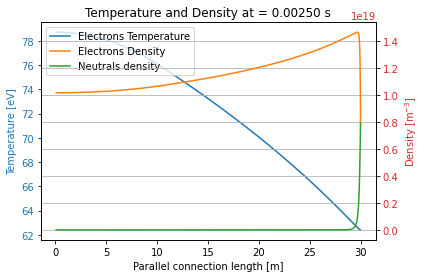

In [4]:
import matplotlib.pyplot as plt


#t va de 0 a 50 porque es todos los steps realizados y el valor de t es la posicion


ds2 = ds.isel(pos = slice(2,-2), t = 50)  # Select domain without guard cells and final timestep
time_value = ds2.t.values.item()
time_str = f"{time_value:.5f}"
print(time_str)



fig, ax1 = plt.subplots()

ds2["Te"].plot(ax = ax1, label = "Electrons Temperature", color='tab:blue')
ax1.set_xlabel("Parallel connection length [m]")


ax1.set_ylabel("Temperature [eV]", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')


# creation of the new y axis scale
ax_den = ax1.twinx()
ds2["Ne"].plot(ax = ax_den, label = "Electrons Density", color='tab:orange')
ds2["Nd"].plot(ax = ax_den, label = "Neutrals density", color='tab:green')

ax_den.set_ylabel("Density [m$^{-3}$]", color='tab:red')
ax_den.tick_params(axis='y', labelcolor='tab:red')

ax1.set_title("Temperature and Density at = "+time_str+" s")
ax_den.set_title("")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax_den.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.grid(True)
plt.show()
